In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
df = pd.read_csv("email_spam_detection (1).csv")

In [4]:
df.head()

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,1,,Meeting,NaN,99,-1,7,0,0
1,2,user1@outlook.com,Security Alert,87.0,2,3,8,0,0
2,3,user2@yahoo.com,Win Prize,69.0,0,3,8,0,0
3,4,user3@gmail.com,Invoice,61.0,0,3,8,0,0
4,5,user4@company.com,Meeting,99.0,2,3,5,0,0


In [5]:
df.tail()

,Email_ID,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
6995,6996,user6995@gmail.com,Greetings,93.0,1,2,6,1,0
6996,6997,user6996@yahoo.com,Offer,107.0,0,0,7,0,0
6997,6998,user6997@gmail.com,Account Verification,222.0,7,14,17,0,1
6998,6999,user6998@outlook.com,Win Prize,164.0,6,16,8,1,1
6999,7000,user6999@company.com,Greetings,168.0,1,17,55,1,1


In [6]:
df.shape

(7000, 9)

In [7]:
df.columns

Index(['Email_ID', 'Sender_Email', 'Subject', 'Email_Length', 'Num_Links',
       'Num_Special_Chars', 'Capital_Words', 'Has_Attachment', 'Spam'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Email_ID           7000 non-null   int64  
 1   Sender_Email       6999 non-null   object 
 2   Subject            7000 non-null   object 
 3   Email_Length       6959 non-null   float64
 4   Num_Links          7000 non-null   int64  
 5   Num_Special_Chars  7000 non-null   int64  
 6   Capital_Words      7000 non-null   int64  
 7   Has_Attachment     7000 non-null   int64  
 8   Spam               7000 non-null   int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 492.3+ KB


In [9]:
df.describe()

,Email_ID,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
count,7000.000000,6959.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,3500.500000,110.567898,2.454571,6.636429,12.199714,0.260714,0.305143
std,2020.870275,52.353566,5.319235,6.123388,15.169749,0.439056,0.460501
min,1.000000,20.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,1750.750000,70.000000,0.000000,2.000000,3.000000,0.000000,0.000000
50%,3500.500000,95.000000,1.000000,4.000000,6.000000,0.000000,0.000000
75%,5250.250000,158.000000,3.000000,11.000000,10.250000,1.000000,1.000000
max,7000.000000,265.000000,99.000000,28.000000,59.000000,1.000000,1.000000


In [10]:
df.dtypes

Email_ID               int64
Sender_Email          object
Subject               object
Email_Length         float64
Num_Links              int64
Num_Special_Chars      int64
Capital_Words          int64
Has_Attachment         int64
Spam                   int64
dtype: object

In [11]:
df.isnull().sum()

Email_ID              0
Sender_Email          1
Subject               0
Email_Length         41
Num_Links             0
Num_Special_Chars     0
Capital_Words         0
Has_Attachment        0
Spam                  0
dtype: int64

In [12]:
(df.isnull().sum()/len(df))*100

Email_ID             0.000000
Sender_Email         0.014286
Subject              0.000000
Email_Length         0.585714
Num_Links            0.000000
Num_Special_Chars    0.000000
Capital_Words        0.000000
Has_Attachment       0.000000
Spam                 0.000000
dtype: float64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop("Email_ID",axis=1,inplace=True)

In [15]:
df.head()

,Sender_Email,Subject,Email_Length,Num_Links,Num_Special_Chars,Capital_Words,Has_Attachment,Spam
0,,Meeting,NaN,99,-1,7,0,0
1,user1@outlook.com,Security Alert,87.0,2,3,8,0,0
2,user2@yahoo.com,Win Prize,69.0,0,3,8,0,0
3,user3@gmail.com,Invoice,61.0,0,3,8,0,0
4,user4@company.com,Meeting,99.0,2,3,5,0,0


In [16]:
df['Sender_Email'].replace('', np.nan, inplace=True)
df.dropna(subset=['Sender_Email'], inplace=True)


In [17]:
df['Email_Length'].fillna(df['Email_Length'].median(), inplace=True)


In [18]:
df.drop_duplicates(inplace=True)


In [19]:
df.dtypes
df['Email_Length'] = pd.to_numeric(df['Email_Length'], errors='coerce')


In [20]:
df['Num_Special_Chars'].replace(-1, np.nan, inplace=True)
df.loc[df['Num_Links'] == 99, 'Num_Links'] = np.nan

In [21]:
df['Num_Special_Chars'].fillna(df['Num_Special_Chars'].median(), inplace=True)
df['Num_Links'].fillna(df['Num_Links'].median(), inplace=True)


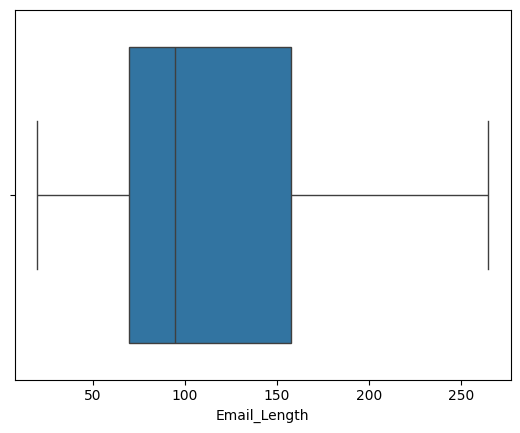

In [22]:
import matplotlib.pyplot as plt

sns.boxplot(x=df['Email_Length'])
plt.show()


In [23]:
(df.isnull().sum()/len(df))*100

Sender_Email         0.0
Subject              0.0
Email_Length         0.0
Num_Links            0.0
Num_Special_Chars    0.0
Capital_Words        0.0
Has_Attachment       0.0
Spam                 0.0
dtype: float64

In [24]:
df['Spam'].value_counts(normalize=True)


Spam
0    0.694956
1    0.305044
Name: proportion, dtype: float64

In [25]:
df.to_csv("email_spam_detection_cleaned.csv", index=False)


In [27]:
X=df[['Email_Length', 'Num_Links', 'Num_Special_Chars']]
y=df['Spam']
X
y

0       0
1       0
2       0
3       0
4       0
       ..
6995    0
6996    0
6997    1
6998    1
6999    1
Name: Spam, Length: 6999, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test,  y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape :" ,y_train.shape)
print("Testing Target Shape:", y_test.shape)




Training Features Shape : (5599, 3)
Testing Features Shape: (1400, 3)
Training Target Shape : (5599,)
Testing Target Shape: (1400,)


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
model1=LogisticRegression()
model2=DecisionTreeClassifier()



In [30]:
model1.fit(X_train,y_train)
model2.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [31]:
y_pred1=model1.predict(X_test)
y_pred2=model2.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy of Logistic Regression:", accuracy_score(y_test, y_pred1))
print("\nAccuracy of Decision Tree:", accuracy_score(y_test, y_pred2))

print("Confusion Matrix (Logistic Regression):")
pd.DataFrame(confusion_matrix(y_test, y_pred1))

print("Confusion Matrix (Decision Tree):")
pd.DataFrame(confusion_matrix(y_test, y_pred2))

Accuracy of Logistic Regression: 0.9992857142857143

Accuracy of Decision Tree: 0.9992857142857143
Confusion Matrix (Logistic Regression):
Confusion Matrix (Decision Tree):


,0,1
0,963,1
1,0,436


In [33]:
new_email=pd.DataFrame({"Email_Length":180, "Num_Links":4, "Num_Special_Chars" : 4}, index=[0])
pred1=model1.predict(new_email)
pred2=model2.predict(new_email)
print(pred1)
print(pred2)


[1]
[1]


In [34]:
import json
from datetime import datetime

logistic_json = {
    "model_type": "LogisticRegression",
    "created_at": datetime.now().isoformat(),
    "features": ["Email_Length", "Num_Links", "Num_Special_Chars"],
    "target": "Spam",
    "coefficients": model1.coef_[0].tolist(),
    "intercept": model1.intercept_.tolist(),
    "classes": model1.classes_.tolist(),
    "accuracy": round(accuracy_score(y_test, y_pred1), 4)
}

with open("spam_logistic_model.json", "w") as f:
    json.dump(logistic_json, f, indent=4)

print("Saved: spam_logistic_model.json")

Saved: spam_logistic_model.json


In [35]:
import json, math

with open("spam_logistic_model.json") as f:
    m = json.load(f)

def predict_spam(email_length, num_links, num_special_chars):
    x = [email_length, num_links, num_special_chars]
    z = sum(c * xi for c, xi in zip(m["coefficients"], x)) + m["intercept"][0]
    prob = 1 / (1 + math.exp(-z))
    return {"prediction": int(prob >= 0.5), "spam_probability": round(prob, 4)}

print(predict_spam(180, 4, 4))

{'prediction': 1, 'spam_probability': 0.981}
